# COHORT ANALYSIS

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r"C:\Users\georg\OneDrive\Desktop\PoweBI practice\Cohort Analysis\online_retail.csv", encoding='ISO-8859-1')

# Preview
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
# removing missing customer IDs
df = df.dropna(subset=['CustomerID'])

In [5]:
#removing negative/zero quantities
df = df[df['Quantity'] > 0]

In [6]:
# convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [8]:
#create total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [9]:
#create cohort variables
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

In [10]:
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'] \
                        .transform('min') \
                        .dt.to_period('M')

In [12]:
#create cohort index
#How many months after first purchase?
def get_cohort_index(df):
    year_diff = df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year
    month_diff = df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month
    return year_diff * 12 + month_diff + 1

df['CohortIndex'] = get_cohort_index(df)

In [13]:
# retention table
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'] \
                .nunique() \
                .reset_index()

In [14]:
cohort_pivot = cohort_data.pivot(index='CohortMonth',
                                columns='CohortIndex',
                                values='CustomerID')

cohort_pivot

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# convert to retention rates
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


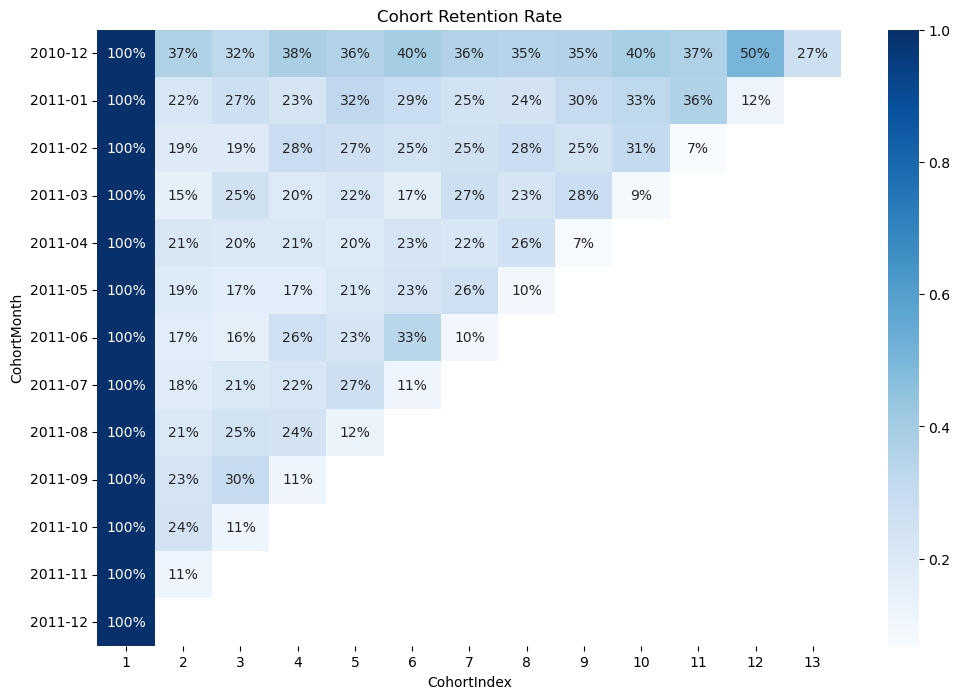

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort Retention Rate")
plt.show()

In [17]:
# create revenue by cohort+time
# How much money does each cohort generate each month after acquisition?
cohort_revenue = df.groupby(['CohortMonth', 'CohortIndex'])['TotalPrice'] \
                   .sum() \
                   .reset_index()

In [18]:
revenue_pivot = cohort_revenue.pivot(index='CohortMonth',
                                    columns='CohortIndex',
                                    values='TotalPrice')

revenue_pivot

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,572713.890,276237.69,233845.37,303119.39,204407.66,336627.50,314162.61,310783.92,331749.220,472813.64,456080.61,513803.59,185803.13
2011-01,293207.350,55149.91,63268.17,71587.40,81114.09,84583.78,70107.40,72689.71,72023.651,111803.90,123882.10,26464.82,NaN
2011-02,158142.070,29043.24,41134.38,48238.86,40147.91,34223.23,49706.63,62450.83,55380.060,64809.45,10600.22,NaN,NaN
2011-03,200069.960,30059.43,59057.51,42816.61,51657.33,40020.81,64919.49,71023.95,71265.830,12868.02,NaN,NaN,NaN
2011-04,122011.491,29452.82,25077.07,24311.47,26314.19,30206.30,28668.98,34228.61,6350.100,NaN,NaN,NaN,NaN
2011-05,124103.780,18682.76,20193.76,19162.17,27861.87,32976.60,33312.91,179251.53,NaN,NaN,NaN,NaN,NaN
2011-06,135742.950,14805.15,14155.40,30961.59,26754.54,42808.25,8227.35,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,74008.751,11789.67,15534.18,17551.47,19512.11,6072.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,79756.100,20962.93,35503.90,44541.76,15284.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
cohort_size = df.groupby('CohortMonth')['CustomerID'].nunique()

In [23]:
# ARPU Analysis
arpu = revenue_pivot.divide(cohort_size, axis=0)

arpu

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,647.134339,312.132983,264.232056,342.507785,230.969107,380.370056,354.986000,351.168271,374.857876,534.252701,515.345322,580.569028,209.94704
2011-01,703.135132,132.253981,151.722230,171.672422,194.518201,202.838801,168.123261,174.315851,172.718588,268.114868,297.079376,63.464796,NaN
2011-02,416.163342,76.429579,108.248368,126.944368,105.652395,90.061132,130.806921,164.344289,145.737000,170.551184,27.895316,NaN,NaN
2011-03,442.632655,66.503164,130.658208,94.727013,114.286128,88.541615,143.627190,157.132633,157.667765,28.469071,NaN,NaN,NaN
2011-04,406.704970,98.176067,83.590233,81.038233,87.713967,100.687667,95.563267,114.095367,21.167000,NaN,NaN,NaN,NaN
2011-05,436.985141,65.784366,71.104789,67.472430,98.105176,116.114789,117.298979,631.167359,NaN,NaN,NaN,NaN,NaN
2011-06,560.921281,61.178306,58.493388,127.940455,110.555950,176.893595,33.997314,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,393.663569,62.711011,82.628617,93.358883,103.787819,32.298723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,471.929586,124.041006,210.082249,263.560710,90.440000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


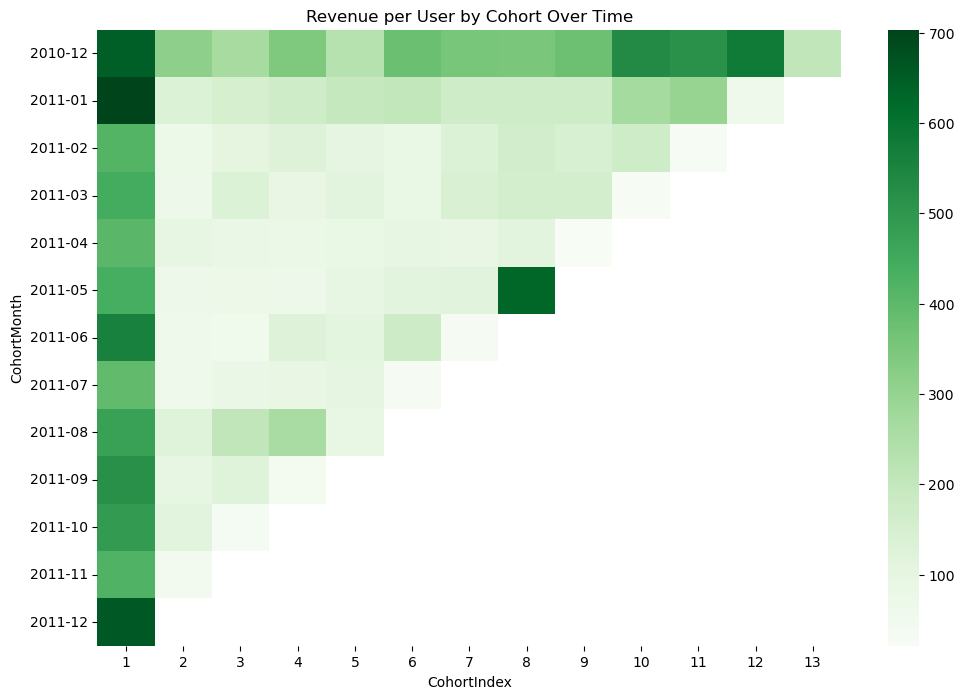

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(arpu, cmap='Greens')
plt.title("Revenue per User by Cohort Over Time")
plt.show()

In [24]:
# identify best and worst cohorts
cohort_total_revenue = revenue_pivot.sum(axis=1).sort_values(ascending=False)
cohort_total_revenue

CohortMonth
2010-12    4512148.220
2011-01    1125882.281
2011-03     643758.940
2011-02     593876.880
2011-05     455545.380
2011-04     326621.031
2011-06     273455.230
2011-09     233296.821
2011-10     227369.540
2011-08     196049.050
2011-11     151876.730
2011-07     144468.341
2011-12      27059.460
Freq: M, dtype: float64

In [25]:
# compare retention vs revenue
retention_summary = cohort_pivot.iloc[:, -1]  # last period retention
revenue_summary = revenue_pivot.sum(axis=1)

comparison = pd.DataFrame({
    'Final_Retention': retention_summary,
    'Total_Revenue': revenue_summary
}).sort_values('Total_Revenue', ascending=False)

comparison

,Final_Retention,Total_Revenue
CohortMonth,,
2010-12,235.0,4512148.220
2011-01,NaN,1125882.281
2011-03,NaN,643758.940
2011-02,NaN,593876.880
2011-05,NaN,455545.380
2011-04,NaN,326621.031
2011-06,NaN,273455.230
2011-09,NaN,233296.821
2011-10,NaN,227369.540


In [26]:
# drop-off point(churn beavior)
retention_decay = retention.copy()
retention_decay

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
#purchase frequency
user_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
user_frequency

CustomerID
12346.0     1
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4339, dtype: int64

In [30]:
#average basket value
basket_value = df.groupby('InvoiceNo')['TotalPrice'].sum()
basket_value

InvoiceNo
536365    139.12
536366     22.20
536367    278.73
536368     70.05
536369     17.85
           ...  
581583    124.60
581584    140.64
581585    329.05
581586    339.20
581587    249.45
Name: TotalPrice, Length: 18536, dtype: float64

In [31]:
cohort_pivot.to_csv("cohort_retention.csv")

In [32]:
revenue_pivot.to_csv("cohort_revenue.csv")

In [33]:
df.to_csv("clean_retail_data.csv", index=False)